In [ ]:
# RETAILVC PYTHON MODULE — EDA (Task 1: General Data Overview)


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import OneHotEncoder

In [3]:
# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

In [19]:
# Load the cleaned marketing campaign data
file_path = "marketing_campaign_clean_file.csv"  # CSV uploaded to working directory
df = pd.read_csv( "C:\\Users\\007bo\\OneDrive\\Desktop\\IIT\\capstone\\3\\marketing_campaign_clean_file.csv")

# Show basic info

print(" Dataset Loaded Successfully!\n")

print("Shape of dataset:", df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary (Numeric Columns) ---")
display(df.describe().T)


 Dataset Loaded Successfully!

Shape of dataset: (2247, 29)

--- First 5 Rows ---


,id,year_birth,age,education,marital_Status,income,kidhome,teenhome,dt_customer,enroll_year,recency,mnt_wines,mnt_fruits,mnt__eat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,Num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,acceptedCmp3,acceptedCmp4,acceptedCmp5,acceptedCmp1,acceptedCmp2,complain,response
0,5524.0,1957.0,68.0,Graduation,Single,58138.0,0.0,0.0,04-09-2012,2012.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,10.0,4.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2174.0,1954.0,71.0,Graduation,Single,46344.0,1.0,1.0,08-03-2014,2014.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4141.0,1965.0,60.0,Graduation,Together,71613.0,0.0,0.0,21-08-2013,2013.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6182.0,1984.0,41.0,Graduation,Together,26646.0,1.0,0.0,10-02-2014,2014.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5324.0,1981.0,44.0,PhD,Married,58293.0,1.0,0.0,19-01-2014,2014.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2237 non-null   float64
 1   year_birth             2237 non-null   float64
 2   age                    2237 non-null   float64
 3   education              2237 non-null   object 
 4   marital_Status         2237 non-null   object 
 5   income                 2237 non-null   float64
 6   kidhome                2237 non-null   float64
 7   teenhome               2237 non-null   float64
 8   dt_customer            2237 non-null   object 
 9   enroll_year            2237 non-null   float64
 10  recency                2237 non-null   float64
 11  mnt_wines              2237 non-null   float64
 12  mnt_fruits             2237 non-null   float64
 13  mnt__eat_products      2237 non-null   float64
 14  mnt_fish_products      2237 non-nu

,count,mean,std,min,25%,50%,75%,max
id,2237.0,5590.726419,3245.118591,0.0,2829.0,5455.0,8427.0,11191.0
year_birth,2237.0,1968.901654,11.701917,1940.0,1959.0,1970.0,1977.0,1996.0
age,2237.0,56.098346,11.701917,29.0,48.0,55.0,66.0,85.0
income,2237.0,52227.413053,25043.266649,1730.0,35523.0,51382.0,68281.0,666666.0
kidhome,2237.0,0.444345,0.538467,0.0,0.0,0.0,1.0,2.0
teenhome,2237.0,0.506482,0.544593,0.0,0.0,0.0,1.0,2.0
enroll_year,2237.0,2013.027716,0.684704,2012.0,2013.0,2013.0,2013.0,2014.0
recency,2237.0,49.104604,28.956073,0.0,24.0,49.0,74.0,99.0
mnt_wines,2237.0,303.995530,336.574382,0.0,24.0,174.0,504.0,1493.0
mnt_fruits,2237.0,26.270451,39.715972,0.0,1.0,8.0,33.0,199.0


In [6]:
# Check Missing Values

missing_data = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={'index': 'Column', 0: 'Missing_Count'})
)
missing_data['Missing_%'] = round(100 * missing_data['Missing_Count'] / len(df), 2)

print("\n--- Missing Values Summary ---")
display(missing_data[missing_data['Missing_Count'] > 0])



--- Missing Values Summary ---


,Column,Missing_Count,Missing_%
0,id,10,0.45
1,year_birth,10,0.45
2,age,10,0.45
3,education,10,0.45
4,marital_Status,10,0.45
5,income,10,0.45
6,kidhome,10,0.45
7,teenhome,10,0.45
8,dt_customer,10,0.45
9,enroll_year,10,0.45


In [18]:
# Convert dt_customer to datetime and print range
df['dt_customer'] = pd.to_datetime(df['dt_customer'], format='%d-%m-%Y', errors='coerce')

print(" Date Range:", df['dt_customer'].min(), "to", df['dt_customer'].max())

 Date Range: 2012-07-30 00:00:00 to 2014-06-29 00:00:00


In [20]:
# Save missing values summary
missing_data.to_csv("eda_missing_values_summary.csv", index=False)
print("\n Missing value summary exported as 'eda_missing_values_summary.csv'")


 Missing value summary exported as 'eda_missing_values_summary.csv'


In [ ]:
----------------------------------------------------------
# Task 2 — Descriptive Statistics & Visualization
----------------------------------------------------------

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
# Create charts folder if it doesn’t exist
os.makedirs("charts", exist_ok=True)

In [23]:
# ---------- Helper: Create total_spent ----------
df['total_spent'] = (
    df['mnt_wines'] + df['mnt_fruits'] + df['mnt__eat_products'] +
    df['mnt_fish_products'] + df['mnt_sweet_products'] + df['mnt_gold_prods']
)

In [24]:
# ---------- Summary stats ----------
print("=== SUMMARY STATISTICS (key numeric variables) ===")
display(df[['income', 'age', 'recency', 'total_spent']].describe().T)


=== SUMMARY STATISTICS (key numeric variables) ===


,count,mean,std,min,25%,50%,75%,max
income,2237.0,52227.413053,25043.266649,1730.0,35523.0,51382.0,68281.0,666666.0
age,2237.0,56.098346,11.701917,29.0,48.0,55.0,66.0,85.0
recency,2237.0,49.104604,28.956073,0.0,24.0,49.0,74.0,99.0
total_spent,2237.0,605.743406,601.840466,5.0,69.0,396.0,1045.0,2525.0


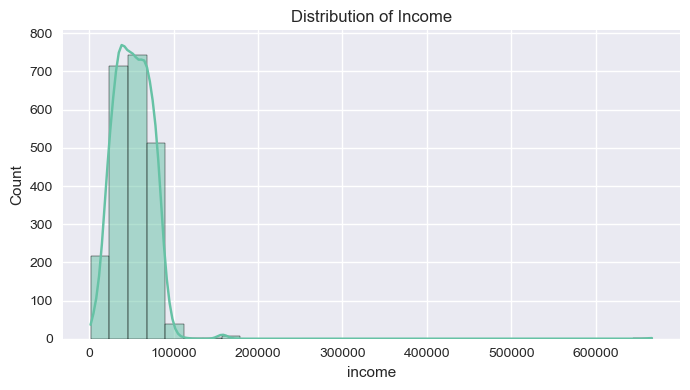

 Histogram for 'income' saved as charts/income_hist.png



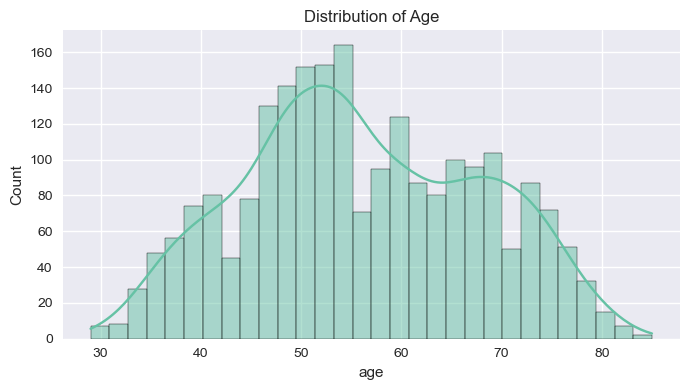

 Histogram for 'age' saved as charts/age_hist.png



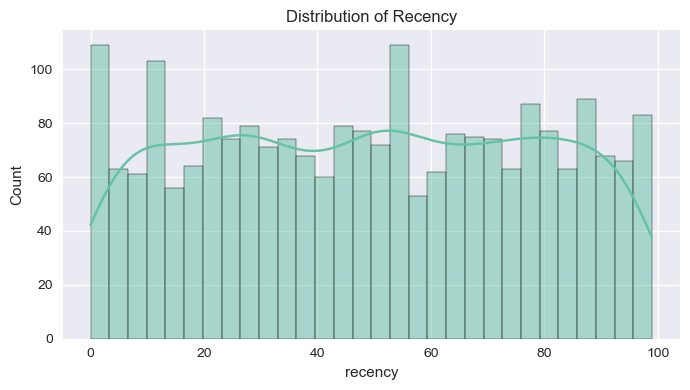

 Histogram for 'recency' saved as charts/recency_hist.png



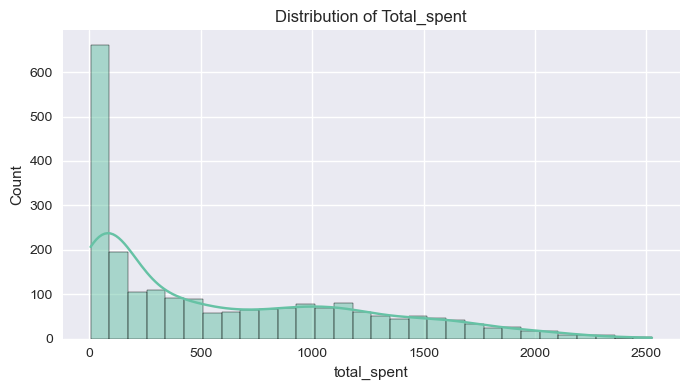

 Histogram for 'total_spent' saved as charts/total_spent_hist.png



In [26]:
# ---------- Histograms ----------
num_vars = ['income', 'age', 'recency', 'total_spent']
for col in num_vars:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"charts/{col}_hist.png", dpi=300)
    plt.show()
    print(f" Histogram for '{col}' saved as charts/{col}_hist.png\n")


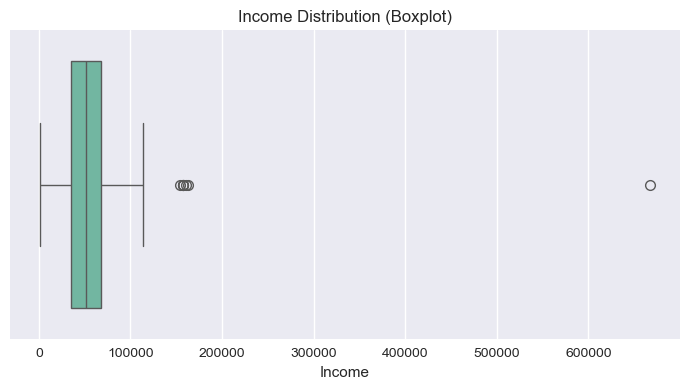

In [27]:
# ---------- Boxplot for income (outlier detection) ----------
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['income'])
plt.title("Income Distribution (Boxplot)")
plt.xlabel("Income")
plt.tight_layout()
plt.savefig("charts/income_boxplot.png", dpi=300)
plt.show()

In [28]:

# ---------- Outlier summary ----------
Q1, Q3 = df['income'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]

print(f"Number of income outliers: {len(outliers)}")
print(f"Outlier threshold: < {lower_bound:.0f} or > {upper_bound:.0f}")


Number of income outliers: 8
Outlier threshold: < -13614 or > 117418


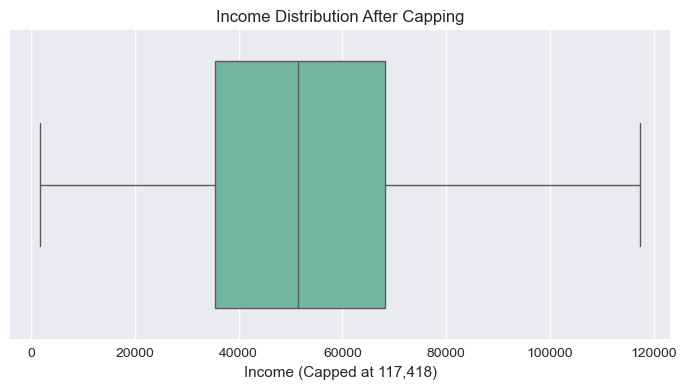

 Income capped successfully. Boxplot saved as 'charts/income_boxplot_capped.png'


In [31]:
# Cap income outliers at upper bound
df['income_capped'] = np.where(df['income'] > upper_bound, upper_bound, df['income'])

# Quick visual check after capping
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['income_capped'])
plt.title("Income Distribution After Capping")
plt.xlabel("Income (Capped at 117,418)")
plt.tight_layout()
plt.savefig("charts/income_boxplot_capped.png", dpi=300)
plt.show()

print(" Income capped successfully. Boxplot saved as 'charts/income_boxplot_capped.png'")


In [ ]:
# Task 3 — Univariate & Categorical Analysis

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [33]:
# Ensure charts folder exists
os.makedirs("charts", exist_ok=True)

In [34]:
# ---------- Categorical Overview ----------
cat_vars = ['education', 'marital_Status']

print("=== CATEGORY DISTRIBUTIONS ===")
for col in cat_vars:
    print(f"\n{col} value counts:\n", df[col].value_counts())


=== CATEGORY DISTRIBUTIONS ===

education value counts:
 education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

marital_Status value counts:
 marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


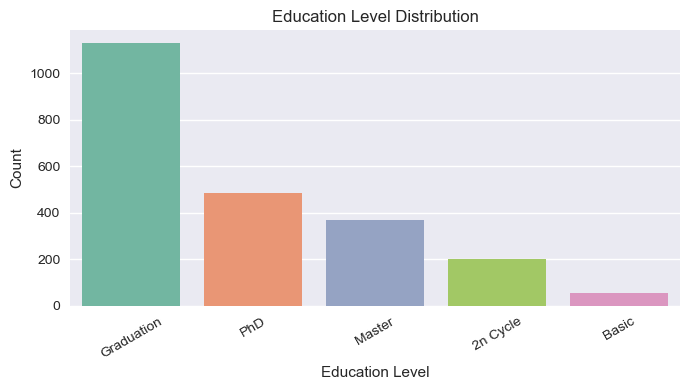

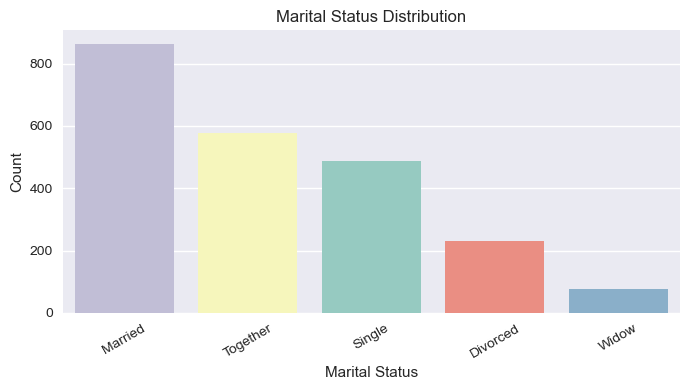

In [36]:
# ---------- Bar plots for Education and Marital_Status ----------
# ---------- Education Distribution ----------
plt.figure(figsize=(7, 4))
sns.countplot(x='education', hue='education', data=df,
              order=df['education'].value_counts().index,
              palette='Set2', legend=False)
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/education_distribution.png", dpi=300)
plt.show()

# ---------- Marital Status Distribution ----------
plt.figure(figsize=(7, 4))
sns.countplot(x='marital_Status', hue='marital_Status', data=df,
              order=df['marital_Status'].value_counts().index,
              palette='Set3', legend=False)
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/marital_status_distribution.png", dpi=300)
plt.show()


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from IPython.display import display

# Silence non-critical warnings for a clean notebook
warnings.filterwarnings("ignore")

# Ensure output folders
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [45]:
# --- 1) Create / confirm age_group (same bins used earlier) ---
bins = [17, 25, 35, 45, 55, 65, 75, 120]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '75+']

# create age_group if not already created (idempotent)
if 'age_group' not in df.columns or not pd.api.types.is_categorical_dtype(df['age_group']):
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
    # add Unknown category for any missing ages
    df['age_group'] = df['age_group'].cat.add_categories(['Unknown']).fillna('Unknown')

print("Age groups created. Example value counts:")
display(df['age_group'].value_counts().reindex(labels + ['Unknown']).fillna(0))


Age groups created. Example value counts:


age_group
18-25        0
26-35       61
36-45      363
46-55      740
56-65      506
66-75      460
75+        107
Unknown     10
Name: count, dtype: int64

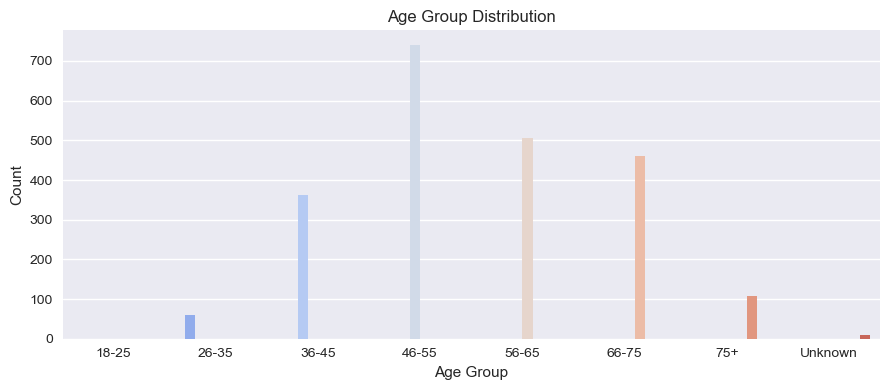

Saved: charts/age_group_distribution.png


In [46]:
# --- 2) Age group distribution (clean, displayed + saved) ---
plt.figure(figsize=(9,4))
sns.countplot(
    data=df,
    x='age_group',
    order=labels + ['Unknown'],
    hue='age_group',    # explicitly set hue to avoid future warnings
    palette='coolwarm',
    legend=False
)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
age_group_img = "charts/age_group_distribution.png"
plt.savefig(age_group_img, dpi=300)
plt.show()
plt.close()
print(f"Saved: {age_group_img}")

In [47]:
# --- 3) Cross-tab: Response vs Education (counts + percent) ---
edu_ct = pd.crosstab(df['education'], df['response']).sort_index()
edu_pct = pd.crosstab(df['education'], df['response'], normalize='index') * 100

# Display and export
print("\nResponse vs Education — counts")
display(edu_ct)
print("\nResponse vs Education — percent (by education)")
display(edu_pct.round(2))

edu_ct.to_csv("outputs/response_by_education_counts.csv")
edu_pct.round(2).to_csv("outputs/response_by_education_pct.csv")
print("Saved: outputs/response_by_education_counts.csv and ..._pct.csv")




Response vs Education — counts


response,0.0,1.0
education,,
2n Cycle,179,22
Basic,52,2
Graduation,975,152
Master,313,57
PhD,384,101



Response vs Education — percent (by education)


response,0.0,1.0
education,,
2n Cycle,89.05,10.95
Basic,96.30,3.70
Graduation,86.51,13.49
Master,84.59,15.41
PhD,79.18,20.82


Saved: outputs/response_by_education_counts.csv and ..._pct.csv


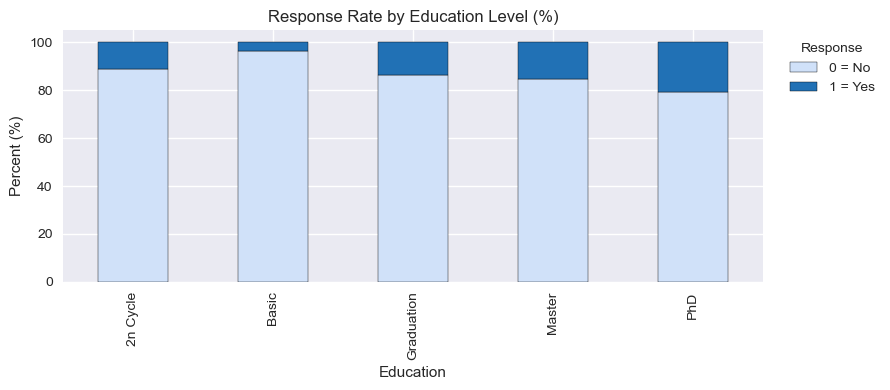

Saved: charts/response_by_education.png


In [48]:
# stacked percent bar (education)
ax = edu_pct.plot(kind='bar', stacked=True, figsize=(9,4), color=['#d0e1f9','#2171b5'], edgecolor='k')
ax.set_title("Response Rate by Education Level (%)")
ax.set_ylabel("Percent (%)")
ax.set_xlabel("Education")
plt.legend(title="Response", labels=["0 = No","1 = Yes"], bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
edu_img = "charts/response_by_education.png"
plt.savefig(edu_img, dpi=300)
plt.show()
plt.close()
print(f"Saved: {edu_img}")

In [49]:
# One-line interpretation
edu_top = (edu_pct[1].sort_values(ascending=False).index[0], round(edu_pct[1].max(),2))
print(f"Interpretation: Highest responder share by education: {edu_top[0]} (~{edu_top[1]}% responded).")

Interpretation: Highest responder share by education: PhD (~20.82% responded).


In [50]:
# --- 4) Cross-tab: Response vs Marital Status (counts + percent) ---
mar_ct = pd.crosstab(df['marital_Status'], df['response']).sort_index()
mar_pct = pd.crosstab(df['marital_Status'], df['response'], normalize='index') * 100

print("\nResponse vs Marital_Status — counts")
display(mar_ct)
print("\nResponse vs Marital_Status — percent (by marital status)")
display(mar_pct.round(2))

mar_ct.to_csv("outputs/response_by_marital_counts.csv")
mar_pct.round(2).to_csv("outputs/response_by_marital_pct.csv")
print("Saved: outputs/response_by_marital_counts.csv and ..._pct.csv")


Response vs Marital_Status — counts


response,0.0,1.0
marital_Status,,
Divorced,183,48
Married,766,98
Single,377,109
Together,519,60
Widow,58,19



Response vs Marital_Status — percent (by marital status)


response,0.0,1.0
marital_Status,,
Divorced,79.22,20.78
Married,88.66,11.34
Single,77.57,22.43
Together,89.64,10.36
Widow,75.32,24.68


Saved: outputs/response_by_marital_counts.csv and ..._pct.csv


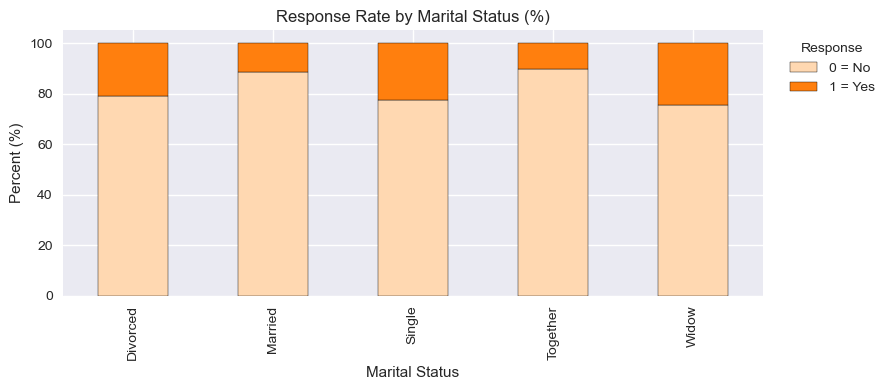

Saved: charts/response_by_marital_status.png


In [51]:
# stacked percent bar (marital status)
ax = mar_pct.plot(kind='bar', stacked=True, figsize=(9,4), color=['#ffd8b1','#ff7f0e'], edgecolor='k')
ax.set_title("Response Rate by Marital Status (%)")
ax.set_ylabel("Percent (%)")
ax.set_xlabel("Marital Status")
plt.legend(title="Response", labels=["0 = No","1 = Yes"], bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
mar_img = "charts/response_by_marital_status.png"
plt.savefig(mar_img, dpi=300)
plt.show()
plt.close()
print(f"Saved: {mar_img}")

In [52]:
# One-line interpretation
mar_top = (mar_pct[1].sort_values(ascending=False).index[0], round(mar_pct[1].max(),2))
print(f"Interpretation: Highest responder share by marital status: {mar_top[0]} (~{mar_top[1]}% responded).")


Interpretation: Highest responder share by marital status: Widow (~24.68% responded).


In [53]:
# --- 5) Save a short summary table combining counts + response rate by age_group (useful next steps) ---
age_summary = df.groupby('age_group').agg(
    customers = ('id','count'),
    mean_income = ('income', 'mean'),
    median_total_spent = ('total_spent','median'),
    response_rate_pct = ('response', 'mean')
)
age_summary['response_rate_pct'] = (age_summary['response_rate_pct']*100).round(2)
age_summary = age_summary.reindex(labels + ['Unknown']).fillna(0)
age_summary.to_csv("outputs/age_group_summary.csv")
print("Saved: outputs/age_group_summary.csv (customers, mean_income, median_total_spent, response_rate%)")

Saved: outputs/age_group_summary.csv (customers, mean_income, median_total_spent, response_rate%)


In [54]:
# Final short confirmation
print("\n Task 3 continuation finished — charts and CSVs saved in 'charts/' and 'outputs/' folders.")


 Task 3 continuation finished — charts and CSVs saved in 'charts/' and 'outputs/' folders.


In [ ]:
 TASK 4 — BIVARIATE & CORRELATION ANALYSIS (CLEAN, WARNING-FREE)

In [55]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
from IPython.display import display


In [56]:
# Suppress warnings
warnings.filterwarnings("ignore")

# Ensure charts directory
os.makedirs("charts", exist_ok=True)

In [65]:
# ---------- 1️ CORRELATION MATRIX ----------
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display top 10 correlated pairs (absolute values)
corr_pairs = (
    corr_matrix.unstack()
    .sort_values(key=lambda x: abs(x), ascending=False)
    .drop_duplicates()
)
print("=== Top 10 Absolute Correlations ===")
display(corr_pairs.head(10))


=== Top 10 Absolute Correlations ===


id                     id                   1.000000
year_birth             age                 -1.000000
mnt_wines              total_spent          0.891734
income_capped          income               0.882615
mnt__eat_products      total_spent          0.842655
total_spent            income_capped        0.804182
num_catalog_purchases  total_spent          0.778375
                       mnt__eat_products    0.723519
mnt_wines              income_capped        0.705080
num_catalog_purchases  income_capped        0.690647
dtype: float64

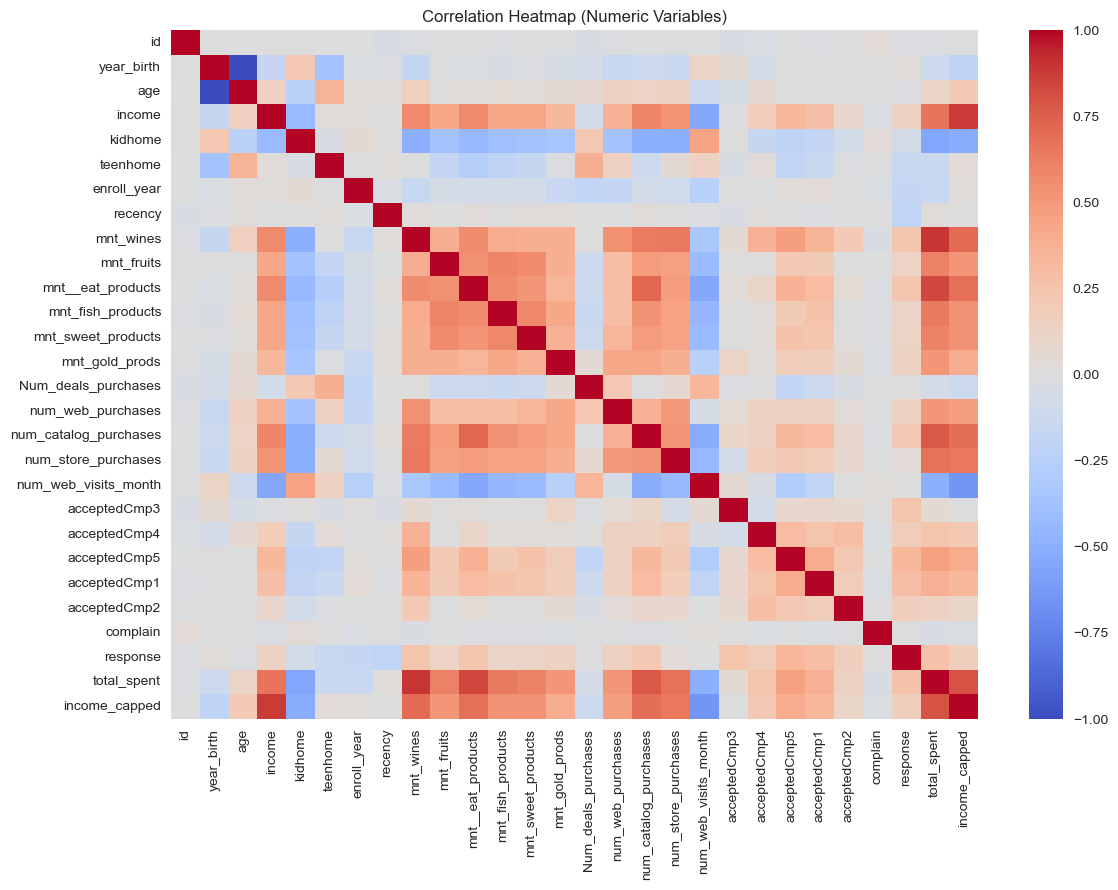

 Saved: charts/correlation_heatmap.png


In [66]:
# Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=300)
plt.show()
plt.close()
print(" Saved: charts/correlation_heatmap.png")


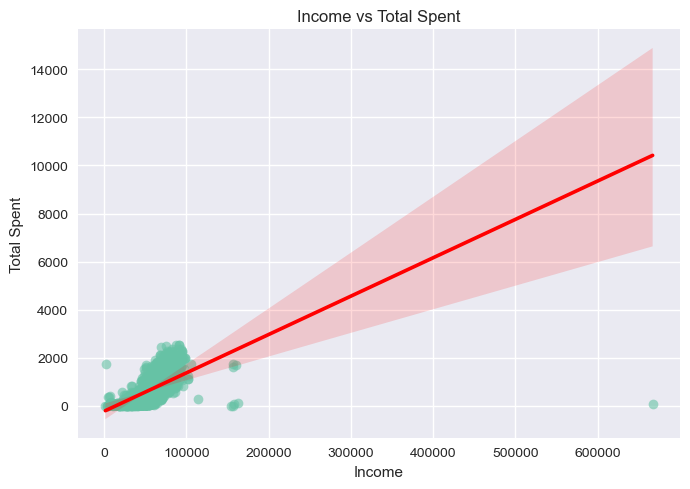

In [59]:
# ---------- 2️ SCATTER PLOTS ----------
# income vs total_spent
plt.figure(figsize=(7, 5))
sns.regplot(x='income', y='total_spent', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Income vs Total Spent")
plt.xlabel("Income")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.savefig("charts/income_vs_total_spent.png", dpi=300)
plt.show()
plt.close()


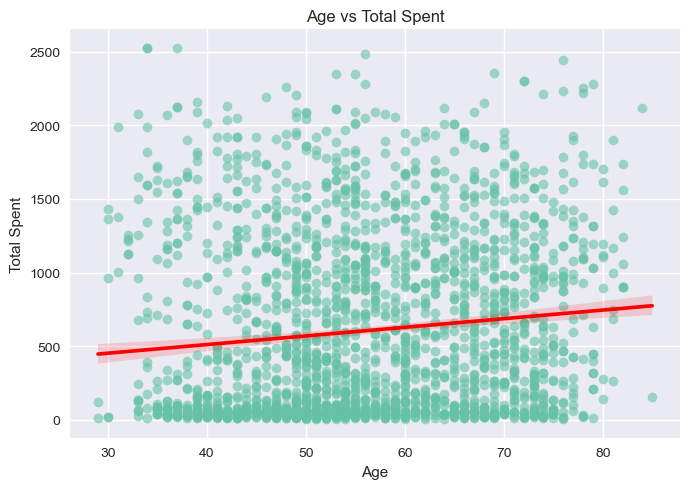

 Saved: charts/income_vs_total_spent.png and charts/age_vs_total_spent.png


In [67]:
# age vs total_spent
plt.figure(figsize=(7, 5))
sns.regplot(x='age', y='total_spent', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Age vs Total Spent")
plt.xlabel("Age")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.savefig("charts/age_vs_total_spent.png", dpi=300)
plt.show()
plt.close()

print(" Saved: charts/income_vs_total_spent.png and charts/age_vs_total_spent.png")


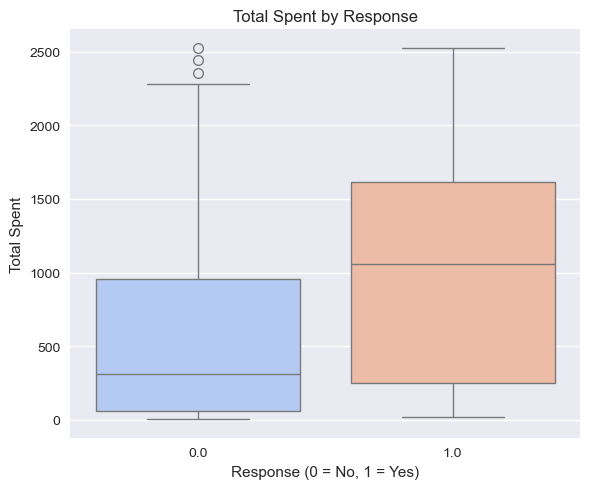

 Saved: charts/total_spent_by_response.png


In [68]:
# ---------- 3️ BOX PLOT: TOTAL SPENT vs RESPONSE ----------
plt.figure(figsize=(6, 5))
sns.boxplot(x='response', y='total_spent', data=df, palette='coolwarm')
plt.title("Total Spent by Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.savefig("charts/total_spent_by_response.png", dpi=300)
plt.show()
plt.close()
print(" Saved: charts/total_spent_by_response.png")

In [69]:
# ---------- 4️ STATISTICAL TEST: Income difference between responders and non-responders ----------
# Split data by response
responders = df[df['response'] == 1]['income']
non_responders = df[df['response'] == 0]['income']

# Drop NaN
responders = responders.dropna()
non_responders = non_responders.dropna()

# Normality check (Shapiro-Wilk)
shapiro_resp = stats.shapiro(responders.sample(min(len(responders), 500), random_state=42))
shapiro_non = stats.shapiro(non_responders.sample(min(len(non_responders), 500), random_state=42))

print("\n=== Normality Check (Shapiro-Wilk) ===")
print(f"Responders p-value: {shapiro_resp.pvalue:.4f}")
print(f"Non-Responders p-value: {shapiro_non.pvalue:.4f}")


=== Normality Check (Shapiro-Wilk) ===
Responders p-value: 0.0000
Non-Responders p-value: 0.0000


In [71]:
# Decide test
if shapiro_resp.pvalue > 0.05 and shapiro_non.pvalue > 0.05:
    test_name = "Independent t-test"
    stat, p_val = stats.ttest_ind(responders, non_responders, equal_var=False)
else:
    test_name = "Mann-Whitney U test"
    stat, p_val = stats.mannwhitneyu(responders, non_responders)

print(f"\n=== {test_name} Result ===")
print(f"Statistic = {stat:.3f}, p-value = {p_val:.5f}")

# Interpretation
if p_val < 0.05:
    print(" =There is a statistically significant difference in income between responders and non-responders.")
else:
    print(" =No significant difference in income between responders and non-responders.")

print("\n =Task 4 completed successfully. All charts saved to 'charts/' folder.")


=== Mann-Whitney U test Result ===
Statistic = 400349.000, p-value = 0.00000
 =There is a statistically significant difference in income between responders and non-responders.

 =Task 4 completed successfully. All charts saved to 'charts/' folder.


In [77]:
# TASK 5 — FEATURE ENGINEERING FOR MODELING

# (1)— Imports & folders (run once

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Create output folders
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print(" (1) done — imports loaded and output folders created.")
# Interpretation: Environment prepared and folders for charts/outputs created.




 (1) done — imports loaded and output folders created.


In [78]:
# -----------------------
# Part (2) — Recompute total_spent and family_size
# -----------------------
# Ensure expected spend columns exist (if missing, create as zeros)
spend_cols = ['mnt_wines','mnt_fruits','mnt__eat_products','mnt_fish_products','mnt_sweet_products','mnt_gold_prods']
for c in spend_cols:
    if c not in df.columns:
        df[c] = 0.0

# Compute total_spent
df['total_spent'] = (
    df['mnt_wines'] + df['mnt_fruits'] + df['mnt__eat_products'] +
    df['mnt_fish_products'] + df['mnt_sweet_products'] + df['mnt_gold_prods']
)

# Compute family_size (kidhome + teenhome + 2 adults assumed)
df['kidhome'] = df.get('kidhome', 0).fillna(0)
df['teenhome'] = df.get('teenhome', 0).fillna(0)
df['family_size'] = df['kidhome'] + df['teenhome'] + 2

display(df[['id','total_spent','kidhome','teenhome','family_size']].head())
print("Part (2) done — total_spent and family_size created.")
# Interpretation: total_spent and family_size computed and visible.


,id,total_spent,kidhome,teenhome,family_size
0,5524.0,1617.0,0.0,0.0,2.0
1,2174.0,27.0,1.0,1.0,4.0
2,4141.0,776.0,0.0,0.0,2.0
3,6182.0,53.0,1.0,0.0,3.0
4,5324.0,422.0,1.0,0.0,3.0


Part (2) done — total_spent and family_size created.


In [80]:
# -----------------------
# Part (3) — Build frequency & monetary columns (RFM base)
# -----------------------
# Ensure purchase counts exist and compute frequency
df['num_web_purchases'] = df.get('num_web_purchases', 0).fillna(0)
df['num_catalog_purchases'] = df.get('num_catalog_purchases', 0).fillna(0)
df['num_store_purchases'] = df.get('num_store_purchases', 0).fillna(0)

df['frequency'] = df['num_web_purchases'] + df['num_catalog_purchases'] + df['num_store_purchases']
df['monetary'] = df['total_spent']

# Ensure recency exists; if not, create a large placeholder (meaning very old)
if 'recency' not in df.columns:
    df['recency'] = 999

display(df[['id','recency','frequency','monetary']].head())
print("Part (3) done — RFM base columns created (recency, frequency, monetary).")
# Interpretation: frequency and monetary built; recency present or placeholder added.


,id,recency,frequency,monetary
0,5524.0,58.0,22.0,1617.0
1,2174.0,38.0,4.0,27.0
2,4141.0,26.0,20.0,776.0
3,6182.0,26.0,6.0,53.0
4,5324.0,94.0,14.0,422.0


Part (3) done — RFM base columns created (recency, frequency, monetary).


In [82]:
# -----------------------
# Part (4) — Safe qcut helper (use this to create quantile bins)
# -----------------------
def safe_qcut(series, q=5, labels=None):
    """
    Try pd.qcut; if it fails (duplicate edges), fallback to rank-based qcut.
    Returns categorical result compatible with labels.
    """
    try:
        return pd.qcut(series, q=q, labels=labels)
    except Exception:
        ranked = series.rank(method='first')
        return pd.qcut(ranked, q=q, labels=labels)

# quick smoke-test (no output required)
print("Part (4) done — safe_qcut helper defined.")
# Interpretation: safe_qcut ready to produce robust quantile bins.


Part (4) done — safe_qcut helper defined.


In [83]:
# -----------------------
# Part (5) — Score R, F, M (1–5) and compute average
# -----------------------
# Define labels
r_labels = [5,4,3,2,1]   # recency: lower is better -> highest score should be 5
f_labels = [1,2,3,4,5]   # frequency: higher better
m_labels = [1,2,3,4,5]   # monetary: higher better

# Prepare series with safe fills
r_series = df['recency'].fillna(df['recency'].max() + 1)  # missing => very old
f_series = df['frequency'].fillna(0)
m_series = df['monetary'].fillna(0)

# Assign scores using safe_qcut and convert to int
df['R_score'] = safe_qcut(r_series, q=5, labels=r_labels).astype(int)
df['F_score'] = safe_qcut(f_series, q=5, labels=f_labels).astype(int)
df['M_score'] = safe_qcut(m_series, q=5, labels=m_labels).astype(int)

# RFM average (rounded)
df['RFM_Avg'] = ((df['R_score'] + df['F_score'] + df['M_score']) / 3).round(2)

display(df[['id','R_score','F_score','M_score','RFM_Avg']].head())
print("Part (5) done — R, F, M scores assigned and RFM average computed.")
# Interpretation: Each customer now has R, F, M scores (1–5) and an averaged RFM value.


,id,R_score,F_score,M_score,RFM_Avg
0,5524.0,3,5,5,4.33
1,2174.0,4,1,1,2.00
2,4141.0,4,4,4,4.00
3,6182.0,4,2,1,2.33
4,5324.0,1,3,3,2.33


Part (5) done — R, F, M scores assigned and RFM average computed.


,count,proportion
rfm_segment,,
Needs Attention,652,29.02
Potential Loyalists,640,28.48
At Risk,604,26.88
Lost Customers,194,8.63
Loyal Customers,157,6.99


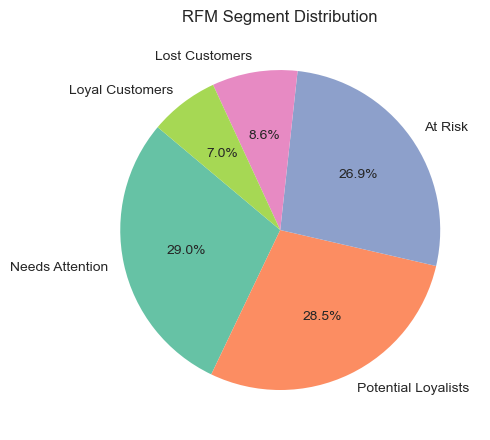

Part (6) done — rfm_segment assigned and pie chart saved to charts/rfm_segment_pie.png


In [86]:
# -----------------------
# Part (6) — Assign human-readable RFM segments
# -----------------------
def assign_segment(avg):
    if avg >= 4.5:
        return 'Loyal Customers'
    elif avg >= 3.5:
        return 'Potential Loyalists'
    elif avg >= 2.5:
        return 'Needs Attention'
    elif avg >= 1.5:
        return 'At Risk'
    else:
        return 'Lost Customers'

df['rfm_segment'] = df['RFM_Avg'].apply(assign_segment)

# Show distribution and save a small pie chart
seg_counts = df['rfm_segment'].value_counts()
seg_pct = (df['rfm_segment'].value_counts(normalize=True) * 100).round(2)
display(pd.concat([seg_counts, seg_pct], axis=1).rename(columns={0:'count',1:'pct'}))
plt.figure(figsize=(5,5))
plt.pie(seg_pct.values, labels=seg_pct.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('RFM Segment Distribution')
plt.tight_layout()
plt.savefig("charts/rfm_segment_pie.png", dpi=300)
plt.show()
print("Part (6) done — rfm_segment assigned and pie chart saved to charts/rfm_segment_pie.png")
# Interpretation: Customers are now segmented by RFM; pie chart exported for reporting.


In [88]:
# -----------------------
# Part (7 )— One-hot encode categorical columns 
# -----------------------
# Choose categorical columns to encode if they exist
cat_cols = [c for c in ['education','marital_Status','age_group','rfm_segment'] if c in df.columns]
print("Categorical columns to encode:", cat_cols)

# Create dummies; drop_first=True to avoid one-hot redundancy
if cat_cols:
    dummies = pd.get_dummies(df[cat_cols].astype(str), drop_first=True, prefix_sep='__')
    print("Created", dummies.shape[1], "dummy columns.")
else:
    dummies = pd.DataFrame(index=df.index)
    print("No categorical columns found to encode.")

# show a sample of dummy columns
display(dummies.head())
print("Part (7) done — one-hot encoding completed.")
# Interpretation: Categorical features converted into numeric dummy columns ready for modeling.



Categorical columns to encode: ['education', 'marital_Status', 'age_group', 'rfm_segment']
Created 20 dummy columns.


,education__Basic,education__Graduation,education__Master,education__PhD,education__nan,marital_Status__Married,marital_Status__Single,marital_Status__Together,marital_Status__Widow,marital_Status__nan,age_group__36-45,age_group__46-55,age_group__56-65,age_group__66-75,age_group__75+,age_group__Unknown,rfm_segment__Lost Customers,rfm_segment__Loyal Customers,rfm_segment__Needs Attention,rfm_segment__Potential Loyalists
0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
1,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
3,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False


Part 7 done — one-hot encoding completed.


In [90]:
# -----------------------
# Part (8) — Build features dataframe and export CSVs
# -----------------------
# Pick numeric columns to include (only ones that exist)
numeric_cols = [c for c in ['age','income','recency','frequency','monetary','total_spent','family_size','num_web_visits_month'] if c in df.columns]
print("Numeric columns included:", numeric_cols)

# Build features_for_model by concatenating numeric + dummies
features_for_model = df[numeric_cols].reset_index(drop=True).copy()
if not dummies.empty:
    features_for_model = pd.concat([features_for_model, dummies.reset_index(drop=True)], axis=1)

# Add target 'response' if present
if 'response' in df.columns:
    features_for_model['response'] = df['response'].reset_index(drop=True)

# Save outputs
clean_path = "outputs/marketing_campaign_clean_for_model.csv"
feature_path = "outputs/features_for_model.csv"
df.to_csv(clean_path, index=False)
features_for_model.to_csv(feature_path, index=False)

print(f"Part (8) done — files saved:\n - {clean_path}\n - {feature_path}")
print("Final quick checks:")
print(" • Clean dataset rows:", df.shape[0])
print(" • Features shape:", features_for_model.shape)
display(features_for_model.head())
# Interpretation: Model-ready CSVs saved and a preview shown for verification.


Numeric columns included: ['age', 'income', 'recency', 'frequency', 'monetary', 'total_spent', 'family_size', 'num_web_visits_month']
Part (8) done — files saved:
 - outputs/marketing_campaign_clean_for_model.csv
 - outputs/features_for_model.csv
Final quick checks:
 • Clean dataset rows: 2247
 • Features shape: (2247, 29)


,age,income,recency,frequency,monetary,total_spent,family_size,num_web_visits_month,education__Basic,education__Graduation,education__Master,education__PhD,education__nan,marital_Status__Married,marital_Status__Single,marital_Status__Together,marital_Status__Widow,marital_Status__nan,age_group__36-45,age_group__46-55,age_group__56-65,age_group__66-75,age_group__75+,age_group__Unknown,rfm_segment__Lost Customers,rfm_segment__Loyal Customers,rfm_segment__Needs Attention,rfm_segment__Potential Loyalists,response
0,68.0,58138.0,58.0,22.0,1617.0,1617.0,2.0,7.0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,1.0
1,71.0,46344.0,38.0,4.0,27.0,27.0,4.0,5.0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,0.0
2,60.0,71613.0,26.0,20.0,776.0,776.0,2.0,4.0,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,0.0
3,41.0,26646.0,26.0,6.0,53.0,53.0,3.0,6.0,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,0.0
4,44.0,58293.0,94.0,14.0,422.0,422.0,3.0,5.0,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0.0


In [92]:
# =============================
# TASK 6 — EXPORT DATA FOR TABLEAU / MODELING
# =============================

import pandas as pd
import os

# Make sure output folder exists
os.makedirs("outputs", exist_ok=True)

# --- 1.. Save clean dataset (with RFM, segments, etc.) ---
clean_path = "outputs/marketing_campaign_clean_for_model.csv"
df.to_csv(clean_path, index=False)
print(f" Clean dataset saved: {clean_path}")

# --- 2.. Save model-ready features (encoded numeric version) ---
feature_path = "outputs/features_for_model.csv"
features_for_model.to_csv(feature_path, index=False)
print(f" Model features saved: {feature_path}")

# --- 3.. Optional smaller summary file for Tableau quick load ---
# Keep only key analytics columns useful for dashboard visuals
cols_for_tableau = [
    'id', 'age', 'income', 'recency', 'frequency', 'monetary',
    'total_spent', 'family_size', 'education', 'marital_Status',
    'age_group', 'rfm_segment', 'response'
]
cols_for_tableau = [c for c in cols_for_tableau if c in df.columns]  # keep only existing columns
tableau_df = df[cols_for_tableau]
tableau_path = "outputs/retailvc_tableau_data.csv"
tableau_df.to_csv(tableau_path, index=False)
print(f" Tableau-ready dataset saved: {tableau_path}")

# --- 4.. Quick confirmation ---
print("\nAll files exported successfully! Use 'retailvc_tableau_data.csv' for Tableau dashboards.")
print("You can use it to create visuals for:")
print(" - RFM segment distribution")
print(" - Response rate by age group or education")
print(" - Income vs total spend correlation")
print(" - Family size or frequency trends")


 Clean dataset saved: outputs/marketing_campaign_clean_for_model.csv
 Model features saved: outputs/features_for_model.csv
 Tableau-ready dataset saved: outputs/retailvc_tableau_data.csv

All files exported successfully! Use 'retailvc_tableau_data.csv' for Tableau dashboards.
You can use it to create visuals for:
 - RFM segment distribution
 - Response rate by age group or education
 - Income vs total spend correlation
 - Family size or frequency trends
